In [10]:
# American Put Option Pricing Methods

# This notebook explains and implements three methods:
# 1. Binomial Tree
# 2. Finite Difference (Implicit / Crank-Nicolson simplified)
# 3. Longstaff-Schwartz Monte Carlo

import numpy as np
from scipy.stats import norm

import matplotlib.pyplot as plt

# Common parameters
S0 = 100
K = 100
r = 0.05
sigma = 0.2
T = 1.0

# --------------------------------------------------
# 1. BINOMIAL TREE METHOD
# --------------------------------------------------

def american_put_binomial(S0, K, r, sigma, T, N):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)

    # Stock price tree
    S = np.zeros((N+1, N+1))
    for i in range(N+1):
        for j in range(i+1):
            S[j, i] = S0 * (u**(i-j)) * (d**j)

    # Option values at maturity
    V = np.maximum(K - S[:, N], 0)

    # Backward induction
    for i in range(N-1, -1, -1):
        for j in range(i+1):
            continuation = np.exp(-r*dt)*(p*V[j] + (1-p)*V[j+1])
            exercise = K - S[j, i]
            V[j] = max(exercise, continuation)

    return V[0]

# Example
print("Binomial price:", american_put_binomial(S0, K, r, sigma, T, 100))

# --------------------------------------------------
# 2. FINITE DIFFERENCE METHOD (CRANK-NICOLSON STYLE)
# --------------------------------------------------


def american_put_cn(S0, K, r, sigma, T, Smax=300, M=200, N=200):

    dt = T/N
    dS = Smax/M

    S = np.linspace(0, Smax, M+1)

    # payoff
    V = np.maximum(K-S,0)

    # coefficients
    i = np.arange(1,M)

    alpha = 0.25*dt*(sigma**2*i**2 - r*i)
    beta  = -0.5*dt*(sigma**2*i**2 + r)
    gamma = 0.25*dt*(sigma**2*i**2 + r*i)

    # matrices
    A = np.diag(1-beta) \
        + np.diag(-alpha[1:], -1) \
        + np.diag(-gamma[:-1], 1)

    B = np.diag(1+beta) \
        + np.diag(alpha[1:], -1) \
        + np.diag(gamma[:-1], 1)

    # backward in time
    for t in range(N):

        rhs = B @ V[1:M]

        # boundary conditions
        rhs[0] += alpha[0]*(K)
        rhs[-1] += gamma[-1]*(0)

        V_inner = np.linalg.solve(A, rhs)

        # early exercise projection
        V[1:M] = np.maximum(K-S[1:M], V_inner)

    return np.interp(S0,S,V)

# Example
print("Finite difference price:", american_put_cn(S0, K, r, sigma, T))

# --------------------------------------------------
# 3. LONGSTAFF-SCHWARTZ MONTE CARLO
# --------------------------------------------------

def american_put_lsm(S0, K, r, sigma, T, N=50, M=10000):
    dt = T / N

    # Simulate paths
    S = np.zeros((M, N+1))
    S[:, 0] = S0

    for t in range(1, N+1):
        Z = np.random.randn(M)
        S[:, t] = S[:, t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)

    # Payoff
    V = np.maximum(K - S[:, -1], 0)

    for t in range(N-1, 0, -1):
        itm = np.where(K - S[:, t] > 0)[0]

        if len(itm) == 0:
            continue

        X = S[itm, t]
        Y = np.exp(-r*dt) * V[itm]

        # Regression (basis: 1, S, S^2)
        A = np.vstack([np.ones(len(X)), X, X**2]).T
        coeffs = np.linalg.lstsq(A, Y, rcond=None)[0]
        continuation = A @ coeffs

        exercise = K - X

        exercise_idx = itm[exercise > continuation]

        V[exercise_idx] = exercise[exercise > continuation]
        V[itm] = np.exp(-r*dt) * V[itm]

    return np.mean(V)

# Example
print("LSM price:", american_put_lsm(S0, K, r, sigma, T))

# --------------------------------------------------
# SUMMARY
# --------------------------------------------------

print("\nSummary:")
print("Binomial: intuitive, slower convergence")
print("Finite Difference: accurate for 1D")
print("LSM Monte Carlo: flexible for high dimensions")


Binomial price: 6.082354409142444
Finite difference price: 6.09002477989934
LSM price: 6.144575949173272

Summary:
Binomial: intuitive, slower convergence
Finite Difference: accurate for 1D
LSM Monte Carlo: flexible for high dimensions



Greeks (Binomial):
{'price': 6.086382749916062, 'delta': -0.41963403740923333, 'gamma': 1.9232157021864538, 'vega': 37.45628214434804}

Greeks (Finite Difference):
{'price': 6.09002477989934, 'delta': -0.41662863743789913, 'gamma': 0.0, 'vega': 37.47886085188159}

Greeks (LSM Monte Carlo):
{'price': 6.204871119770885, 'delta': 8.553110533142139, 'gamma': -3115.2486027093396, 'vega': 40.88383303130758}


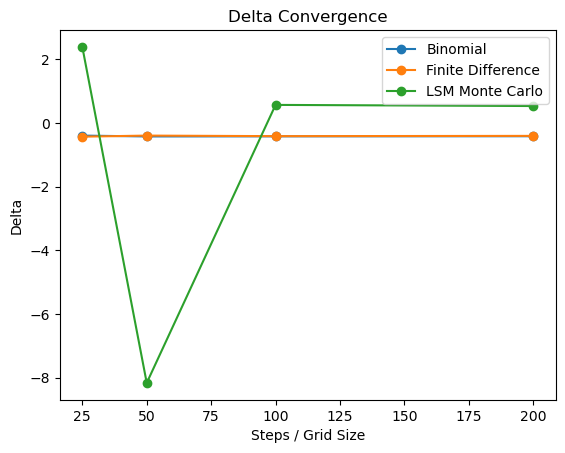

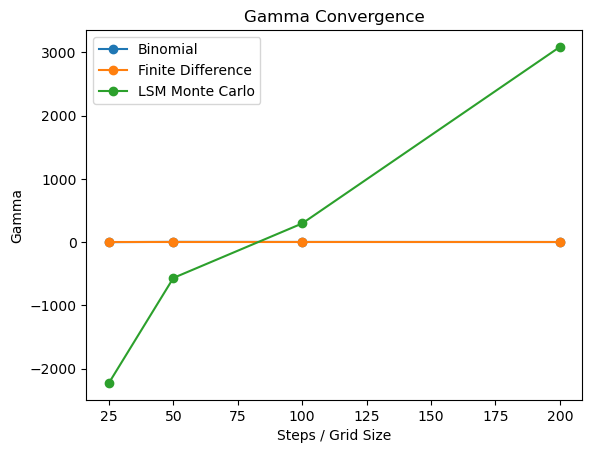

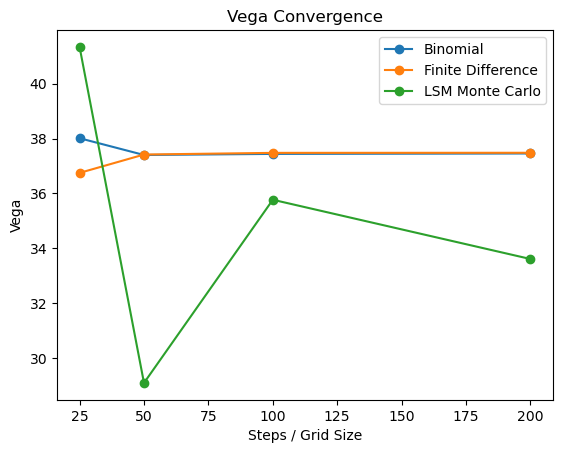

In [11]:

# ==================================================
# Greeks via Bump-and-Revalue
# ==================================================

def compute_greeks(pricer, S0, K, r, sigma, T, eps=1e-2, **kwargs):
    base = pricer(S0, K, r, sigma, T, **kwargs)

    # Delta
    up = pricer(S0 + eps, K, r, sigma, T, **kwargs)
    down = pricer(S0 - eps, K, r, sigma, T, **kwargs)
    delta = (up - down) / (2 * eps)

    # Gamma
    gamma = (up - 2*base + down) / (eps**2)

    # Vega
    up_vol = pricer(S0, K, r, sigma + eps, T, **kwargs)
    down_vol = pricer(S0, K, r, sigma - eps, T, **kwargs)
    vega = (up_vol - down_vol) / (2 * eps)

    return {
        'price': base,
        'delta': delta,
        'gamma': gamma,
        'vega': vega
    }

# ==================================================
# Example Greeks
# ==================================================

print("\nGreeks (Binomial):")
print(compute_greeks(american_put_binomial, S0, K, r, sigma, T, N=200))

print("\nGreeks (Finite Difference):")
print(compute_greeks(american_put_cn, S0, K, r, sigma, T))

print("\nGreeks (LSM Monte Carlo):")
print(compute_greeks(american_put_lsm, S0, K, r, sigma, T, N=50, M=10000))

# ==================================================
# Greek Convergence Plots
# ==================================================

steps = [25, 50, 100, 200]

delta_bin, gamma_bin, vega_bin = [], [], []
delta_fd, gamma_fd, vega_fd = [], [], []
delta_lsm, gamma_lsm, vega_lsm = [], [], []

for n in steps:
    g_bin = compute_greeks(american_put_binomial, S0, K, r, sigma, T, N=n)
    delta_bin.append(g_bin['delta'])
    gamma_bin.append(g_bin['gamma'])
    vega_bin.append(g_bin['vega'])

    g_fd = compute_greeks(american_put_cn, S0, K, r, sigma, T, M=2*n, N=2*n)
    delta_fd.append(g_fd['delta'])
    gamma_fd.append(g_fd['gamma'])
    vega_fd.append(g_fd['vega'])

    g_lsm = compute_greeks(american_put_lsm, S0, K, r, sigma, T, N=n, M=5000)
    delta_lsm.append(g_lsm['delta'])
    gamma_lsm.append(g_lsm['gamma'])
    vega_lsm.append(g_lsm['vega'])

# Plot Delta
plt.figure()
plt.plot(steps, delta_bin, marker='o', label='Binomial')
plt.plot(steps, delta_fd, marker='o', label='Finite Difference')
plt.plot(steps, delta_lsm, marker='o', label='LSM Monte Carlo')
plt.xlabel('Steps / Grid Size')
plt.ylabel('Delta')
plt.title('Delta Convergence')
plt.legend()
plt.show()

# Plot Gamma
plt.figure()
plt.plot(steps, gamma_bin, marker='o', label='Binomial')
plt.plot(steps, gamma_fd, marker='o', label='Finite Difference')
plt.plot(steps, gamma_lsm, marker='o', label='LSM Monte Carlo')
plt.xlabel('Steps / Grid Size')
plt.ylabel('Gamma')
plt.title('Gamma Convergence')
plt.legend()
plt.show()

# Plot Vega
plt.figure()
plt.plot(steps, vega_bin, marker='o', label='Binomial')
plt.plot(steps, vega_fd, marker='o', label='Finite Difference')
plt.plot(steps, vega_lsm, marker='o', label='LSM Monte Carlo')
plt.xlabel('Steps / Grid Size')
plt.ylabel('Vega')
plt.title('Vega Convergence')
plt.legend()
plt.show()
